
# Insurance Lakehouse Teaching Notebook
## DuckDB Bronze → Silver → Gold

This notebook demonstrates a **complete mini Lakehouse pipeline**.

Students learn:

- Bronze ingestion
- Silver transformations
- Gold analytics
- SQL insight queries
- Charts for insights

---

## Lakehouse Architecture

```
Raw Files
   │
   ▼
┌──────────────┐
│   BRONZE     │
│ Raw CSV Data │
└──────────────┘
        │
        ▼
┌──────────────┐
│    SILVER    │
│ Clean Tables │
└──────────────┘
        │
        ▼
┌──────────────┐
│     GOLD     │
│  KPIs / BI   │
└──────────────┘
```


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(".")
BRONZE_DIR = BASE_DIR / "insurance" / "data" / "bronze"

In [4]:
con = duckdb.connect("insurance_lakehouse.duckdb")

## Bronze Layer – Raw Data

In [6]:

con.execute("""
DROP VIEW IF EXISTS bronze_insurance;

CREATE VIEW bronze_insurance AS
SELECT
    *,
    CAST(split_part(filename,'.',2) AS INTEGER) AS year
FROM read_csv_auto(
    'insurance/data/bronze/insurance.*.csv',
    header=true,
    filename=true
);
""")

con.execute("""
SELECT year, 
COUNT(*) AS num_of_rows
FROM bronze_insurance
GROUP BY year
ORDER BY year
""").df()


,year,num_of_rows
0,2021,1300
1,2022,1300
2,2023,1300
3,2024,1300


## Silver Layer – Cleaned Data

In [7]:

con.execute("""
DROP TABLE IF EXISTS silver_insurance;

CREATE TABLE silver_insurance AS
SELECT
    age::INTEGER AS age,
    gender,
    bmi::DOUBLE AS bmi,
    children::INTEGER AS children,
    smoker,
    region,
    charges::DOUBLE AS charges,
    year::INTEGER AS year,

    CASE
        WHEN bmi < 18.5 THEN 'underweight'
        WHEN bmi < 25 THEN 'normal'
        WHEN bmi < 30 THEN 'overweight'
        ELSE 'obese'
    END AS bmi_class,

    CASE
        WHEN age < 30 THEN '18-29'
        WHEN age < 40 THEN '30-39'
        WHEN age < 50 THEN '40-49'
        WHEN age < 60 THEN '50-59'
        ELSE '60+'
    END AS age_band

FROM bronze_insurance
""")

con.execute("""
SELECT year, COUNT(*) AS num_of_rows
FROM silver_insurance
GROUP BY year
ORDER BY year
""").df()


,year,num_of_rows
0,2021,1300
1,2022,1300
2,2023,1300
3,2024,1300


## Gold Layer – KPIs

In [8]:

con.execute("""
DROP VIEW IF EXISTS gold_kpi_year;

CREATE VIEW gold_kpi_year AS
SELECT
    year,
    COUNT(*) members,
    AVG(charges) avg_charges,
    MEDIAN(charges) median_charges,
    SUM(charges) total_charges
FROM silver_insurance
GROUP BY year
ORDER BY year
""")

con.execute("SELECT * FROM gold_kpi_year").df()


,year,members,avg_charges,median_charges,total_charges
0,2021,1300,15748.940800,12738.90,20473623.04
1,2022,1300,16781.303192,13620.14,21815694.15
2,2023,1300,17149.925223,13781.32,22294902.79
3,2024,1300,17726.495423,14547.08,23044444.05


## Insight Queries and Charts

### Average Charges by Year

In [9]:
df = con.execute("""SELECT year, AVG(charges) avg_charges FROM silver_insurance GROUP BY year ORDER BY year""").df()
df

,year,avg_charges
0,2021,15748.940800
1,2022,16781.303192
2,2023,17149.925223
3,2024,17726.495423


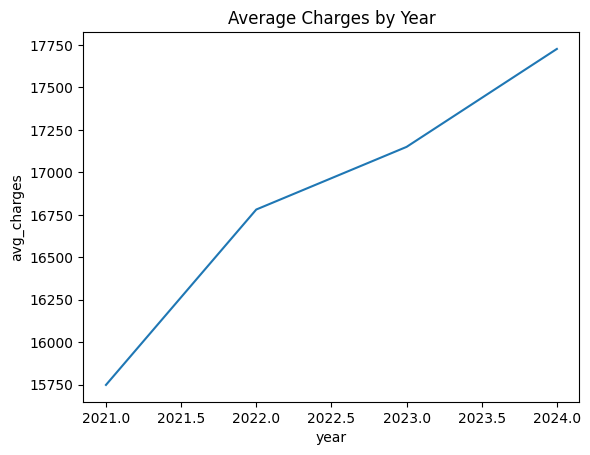

In [10]:

plt.figure()
plt.plot(df["year"], df["avg_charges"])
plt.xlabel("year")
plt.ylabel("avg_charges")
plt.title("Average Charges by Year")
plt.show()


### Charges by Region

In [11]:
df = con.execute("""SELECT region, AVG(charges) avg_charges FROM silver_insurance GROUP BY region""").df()
df

,region,avg_charges
0,southwest,16417.575123
1,southeast,16756.908670
2,northwest,16997.721412
3,northeast,17247.142607


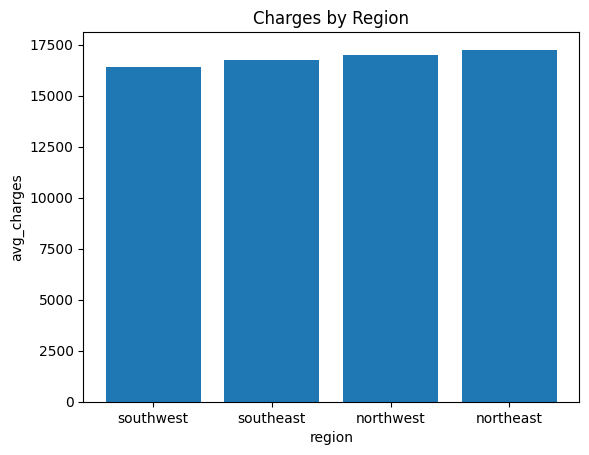

In [12]:

plt.figure()
plt.bar(df["region"].astype(str), df["avg_charges"])
plt.xlabel("region")
plt.ylabel("avg_charges")
plt.title("Charges by Region")
plt.show()


### Charges by Smoker

In [13]:
df = con.execute("""SELECT smoker, AVG(charges) avg_charges FROM silver_insurance GROUP BY smoker""").df()
df

,smoker,avg_charges
0,False,12191.119137
1,True,37149.764367


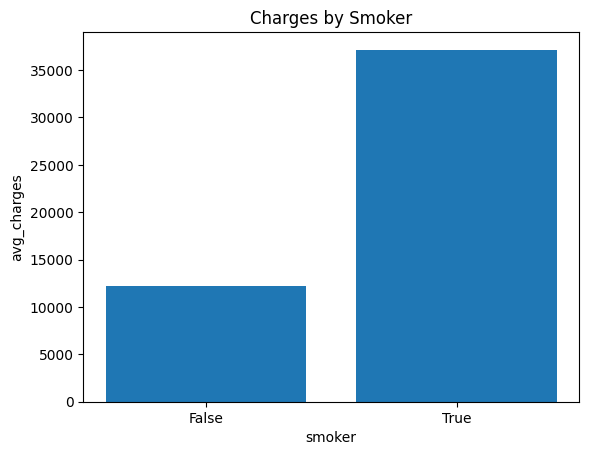

In [14]:

plt.figure()
plt.bar(df["smoker"].astype(str), df["avg_charges"])
plt.xlabel("smoker")
plt.ylabel("avg_charges")
plt.title("Charges by Smoker")
plt.show()


### Charges by BMI Class

In [15]:
df = con.execute("""SELECT bmi_class, AVG(charges) avg_charges FROM silver_insurance GROUP BY bmi_class""").df()
df

,bmi_class,avg_charges
0,overweight,16627.884853
1,underweight,13959.802587
2,obese,17655.707286
3,normal,15311.635395


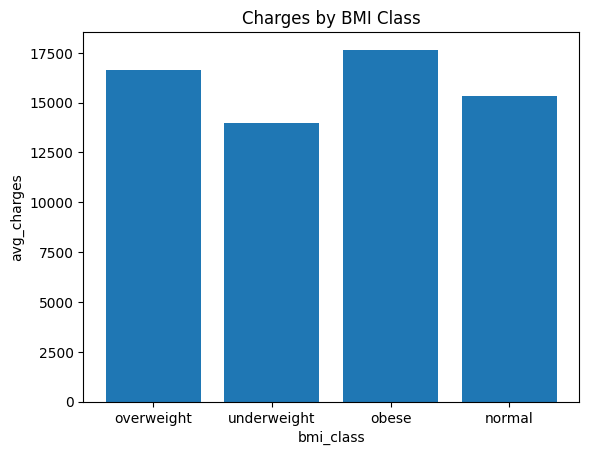

In [16]:

plt.figure()
plt.bar(df["bmi_class"].astype(str), df["avg_charges"])
plt.xlabel("bmi_class")
plt.ylabel("avg_charges")
plt.title("Charges by BMI Class")
plt.show()


### Charges by Age Band

In [17]:
df = con.execute("""SELECT age_band, AVG(charges) avg_charges FROM silver_insurance GROUP BY age_band""").df()
df

,age_band,avg_charges
0,40-49,17705.343004
1,30-39,15223.437437
2,50-59,20410.871182
3,60+,23438.884683
4,18-29,11646.222652


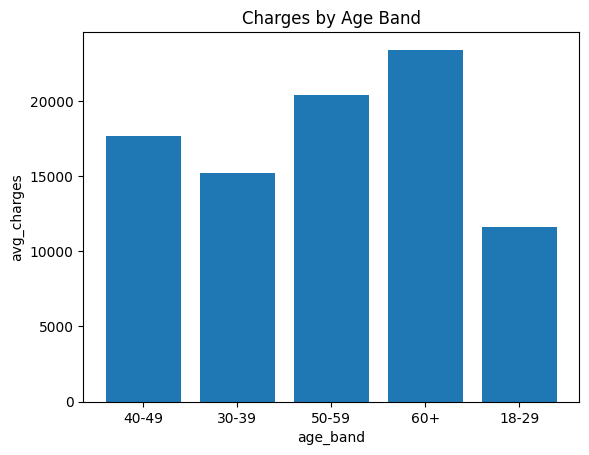

In [18]:

plt.figure()
plt.bar(df["age_band"].astype(str), df["avg_charges"])
plt.xlabel("age_band")
plt.ylabel("avg_charges")
plt.title("Charges by Age Band")
plt.show()


### Total Charges by Year

In [19]:
df = con.execute("""SELECT year, SUM(charges) total_charges FROM silver_insurance GROUP BY year ORDER BY year""").df()
df

,year,total_charges
0,2021,20473623.04
1,2022,21815694.15
2,2023,22294902.79
3,2024,23044444.05


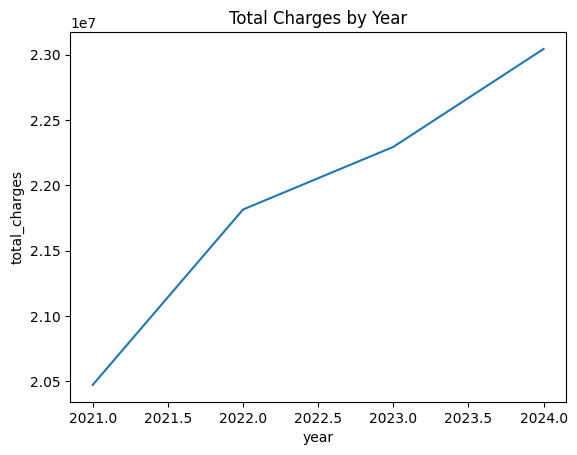

In [20]:

plt.figure()
plt.plot(df["year"], df["total_charges"])
plt.xlabel("year")
plt.ylabel("total_charges")
plt.title("Total Charges by Year")
plt.show()


### Children vs Charges

In [21]:
df = con.execute("""SELECT children, AVG(charges) avg_charges FROM silver_insurance GROUP BY children ORDER BY children""").df()
df

,children,avg_charges
0,0,16381.876405
1,1,16437.449589
2,2,17157.924790
3,3,18387.096235
4,4,19357.598689
5,5,18179.750928


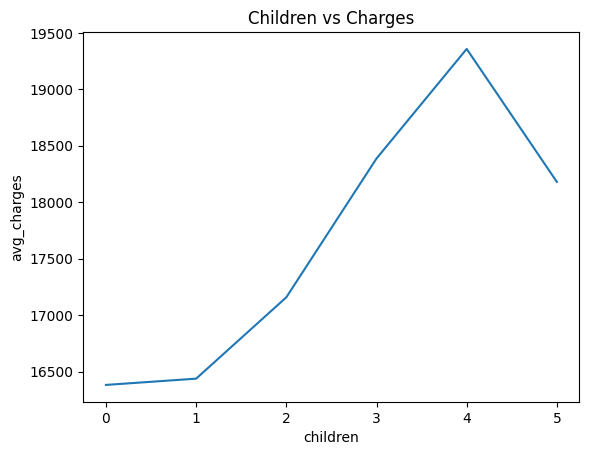

In [22]:

plt.figure()
plt.plot(df["children"], df["avg_charges"])
plt.xlabel("children")
plt.ylabel("avg_charges")
plt.title("Children vs Charges")
plt.show()


### Regional Cost Ranking

In [23]:
df = con.execute("""SELECT region, SUM(charges) total_charges FROM silver_insurance GROUP BY region ORDER BY total_charges DESC""").df()
df

,region,total_charges
0,southeast,25571042.63
1,northwest,22623967.20
2,northeast,20110168.28
3,southwest,19323485.92


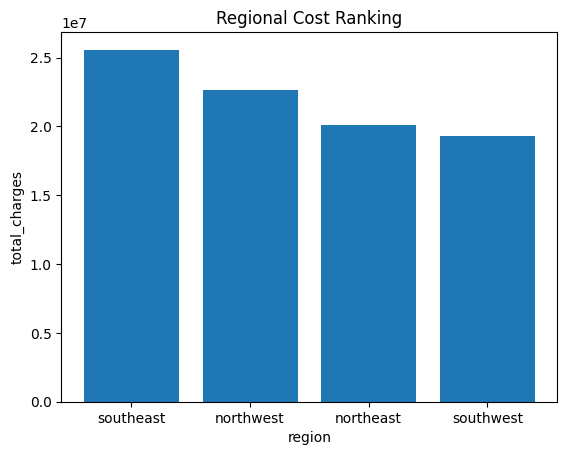

In [24]:

plt.figure()
plt.bar(df["region"].astype(str), df["total_charges"])
plt.xlabel("region")
plt.ylabel("total_charges")
plt.title("Regional Cost Ranking")
plt.show()


### Average BMI by Region

In [25]:
df = con.execute("""SELECT region, AVG(bmi) avg_bmi FROM silver_insurance GROUP BY region""").df()
df

,region,avg_bmi
0,southwest,29.967103
1,southeast,30.145367
2,northwest,30.132863
3,northeast,30.309022


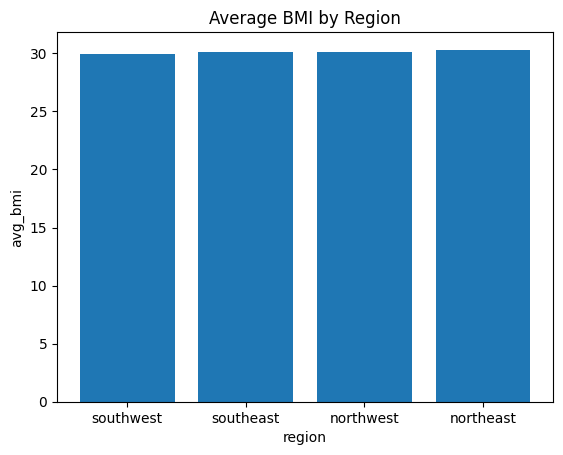

In [26]:

plt.figure()
plt.bar(df["region"].astype(str), df["avg_bmi"])
plt.xlabel("region")
plt.ylabel("avg_bmi")
plt.title("Average BMI by Region")
plt.show()


### Top 20 Charges

In [27]:
df = con.execute("""SELECT age, charges FROM silver_insurance ORDER BY charges DESC LIMIT 20""").df()
df

,age,charges
0,62,61974.25
1,55,61573.60
2,55,61413.30
3,55,59509.57
4,52,59370.34
5,61,59349.88
6,42,56564.29
7,57,56559.54
8,46,56449.88
9,34,55569.29


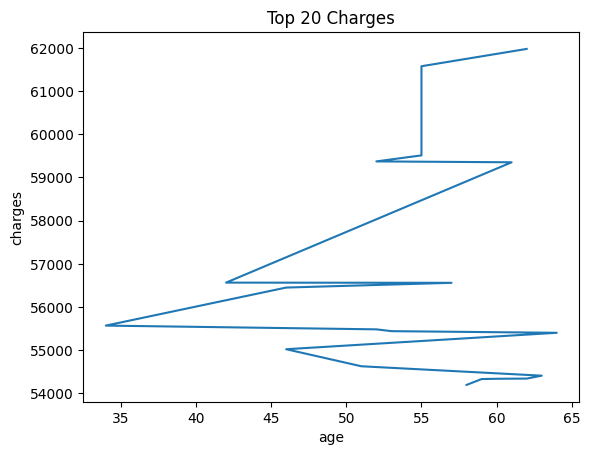

In [28]:

plt.figure()
plt.plot(df["age"], df["charges"])
plt.xlabel("age")
plt.ylabel("charges")
plt.title("Top 20 Charges")
plt.show()



## Data Story

Key insights:

- Smoking status dramatically increases insurance costs
- Charges increase with age
- Higher BMI correlates with higher costs
- A small group of high-cost patients drives overall spending
- Regional cost differences exist but are smaller than lifestyle effects
